# ECG anomaly-detection demo

Inspect both saved autoencoders on held-out normal and anomalous beats.

## Run training once (only if needed)

Run the next cell only if saved models and demo data are missing. If training has already run, skip it because retraining takes time.

In [ ]:
# Run only when saved artifacts are missing or need regeneration.
!cd .. && python scripts/train.py

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
OUTPUTS = Path('../outputs')
if not (OUTPUTS / 'demo_data.npz').exists():
    raise FileNotFoundError('Run the optional training cell first.')
data = np.load(OUTPUTS / 'demo_data.npz')
results = pd.read_csv(OUTPUTS / 'results.csv')
errors = pd.read_csv(OUTPUTS / 'test_errors.csv')
models = results['model'].tolist()

In [2]:
normal_index = int(np.flatnonzero(data['test_anomaly'] == 0)[0])
anomaly_index = int(np.flatnonzero(data['test_anomaly'] == 1)[0])
examples = [('Normal', normal_index), ('Anomalous', anomaly_index)]
rows = []
for kind, index in examples:
    for model in models:
        row = errors[(errors.model == model) & (errors.test_index == index)].iloc[0]
        rows.append({'beat': kind, 'index': index, 'model': model, 'error': row.reconstruction_error, 'threshold': results.loc[results.model.eq(model), 'threshold'].iloc[0], 'prediction': 'Anomalous' if row.prediction else 'Normal'})
pd.DataFrame(rows).round(5)

,beat,index,model,error,threshold,prediction
0,Normal,0,conv_ae,2.28895,1.35478,Anomalous
1,Normal,0,lstm_ae,2.31853,1.07536,Anomalous
2,Anomalous,2627,conv_ae,3.53058,1.35478,Anomalous
3,Anomalous,2627,lstm_ae,3.65751,1.07536,Anomalous


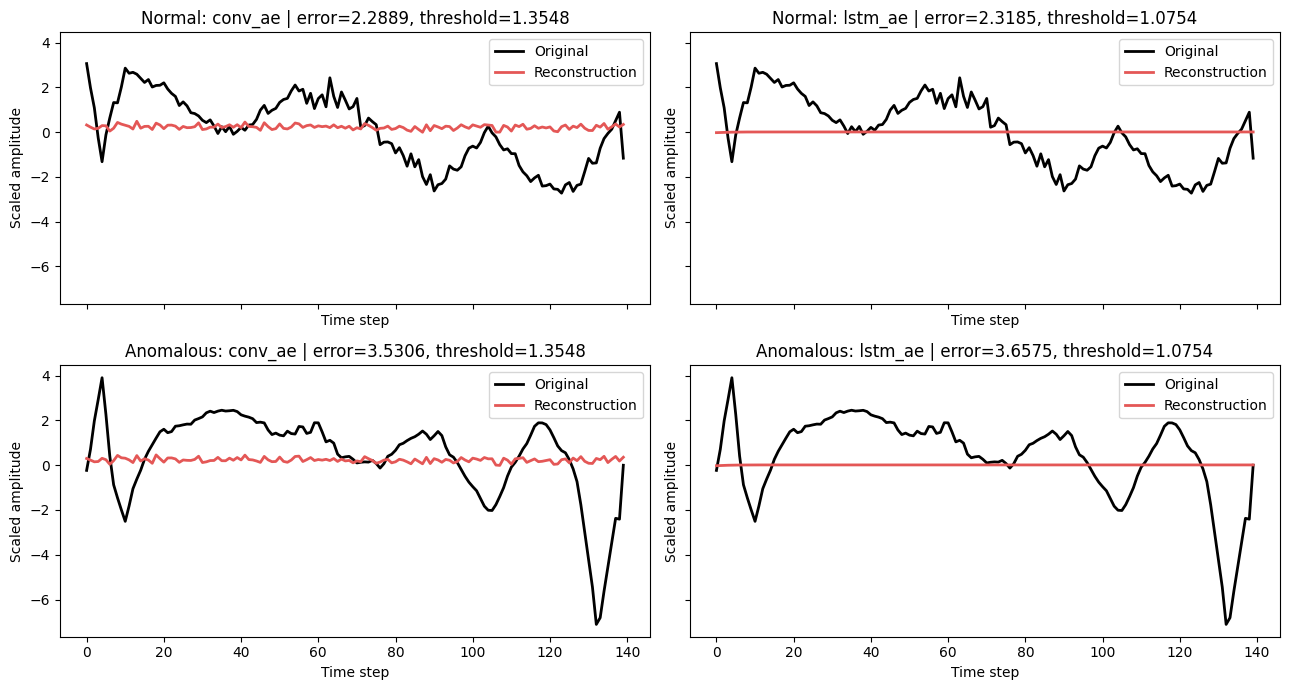

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for row, (kind, index) in enumerate(examples):
    for column, model in enumerate(models):
        axis = axes[row, column]
        axis.plot(data['test'][index], color='black', linewidth=2, label='Original')
        axis.plot(data[f'{model}_reconstruction'][index], color='#E45756', linewidth=2, label='Reconstruction')
        error = data[f'{model}_error'][index]
        threshold = results.loc[results.model.eq(model), 'threshold'].iloc[0]
        axis.set(title=f'{kind}: {model} | error={error:.4f}, threshold={threshold:.4f}', xlabel='Time step', ylabel='Scaled amplitude')
        axis.legend()
plt.tight_layout()
plt.show()